In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ----------------------------
# Activation Functions
# ----------------------------
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)

def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return (Z > 0).astype(float)

def tanh(Z):
    return np.tanh(Z)

def tanh_derivative(A):
    return 1 - np.square(A)

In [3]:
# ----------------------------
# Loss Function (Binary Cross Entropy)
# ----------------------------
def compute_loss(Y, A, weights, lambda_reg=0, reg_type=None):
    m = Y.shape[1]
    loss = -np.mean(Y*np.log(A+1e-8) + (1-Y)*np.log(1-A+1e-8))

    # Regularization
    if reg_type == "L2":
        l2 = sum(np.sum(np.square(w)) for w in weights)
        loss += (lambda_reg/(2*m)) * l2

    elif reg_type == "L1":
        l1 = sum(np.sum(np.abs(w)) for w in weights)
        loss += (lambda_reg/m) * l1

    return loss

In [7]:
# ----------------------------
# Initialize Parameters
# ----------------------------
def initialize(layer_dims):
    np.random.seed(42)
    params = {}
    for i in range(1, len(layer_dims)):
        params["W"+str(i)] = np.random.randn(layer_dims[i], layer_dims[i-1]) * 0.01
        params["b"+str(i)] = np.zeros((layer_dims[i], 1))
    return params


In [10]:
# ----------------------------
# Forward Propagation
# ----------------------------
def forward(X, params, activation="relu"):
    cache = {}
    A = X

    for i in range(1, len(params)//2):
        Z = np.dot(params["W"+str(i)], A) + params["b"+str(i)]
        if activation == "relu":
            A = relu(Z)
        elif activation == "tanh":
            A = tanh(Z)
        elif activation == "sigmoid":
            A = sigmoid(Z)

        cache["A"+str(i)] = A
        cache["Z"+str(i)] = Z

    # Output layer (sigmoid)
    ZL = np.dot(params["W"+str(len(params)//2)], A) + params["b"+str(len(params)//2)]
    AL = sigmoid(ZL)

    cache["A_final"] = AL
    cache["Z_final"] = ZL

    return AL, cache

In [11]:
# Backpropagation
# ----------------------------
def backward(X, Y, params, cache, activation="relu", lambda_reg=0, reg_type=None):
    grads = {}
    m = X.shape[1]
    L = len(params)//2

    AL = cache["A_final"]
    dZ = AL - Y

    for i in reversed(range(1, L+1)):
        A_prev = X if i == 1 else cache["A"+str(i-1)]

        grads["dW"+str(i)] = (1/m) * np.dot(dZ, A_prev.T)
        grads["db"+str(i)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        # Regularization gradients
        if reg_type == "L2":
            grads["dW"+str(i)] += (lambda_reg/m) * params["W"+str(i)]
        elif reg_type == "L1":
            grads["dW"+str(i)] += (lambda_reg/m) * np.sign(params["W"+str(i)])

        if i > 1:
            W = params["W"+str(i)]
            Z_prev = cache["Z"+str(i-1)]

            if activation == "relu":
                dZ = np.dot(W.T, dZ) * relu_derivative(Z_prev)
            elif activation == "tanh":
                dZ = np.dot(W.T, dZ) * tanh_derivative(cache["A"+str(i-1)])
            elif activation == "sigmoid":
                dZ = np.dot(W.T, dZ) * sigmoid_derivative(cache["A"+str(i-1)])

    return grads

In [12]:
# ----------------------------
# Update Parameters
# ----------------------------
def update(params, grads, lr):
    for key in params:
        params[key] -= lr * grads["d"+key]
    return params


In [13]:
# ----------------------------
# Training Function
# ----------------------------
def train(X, Y, layer_dims, activation="relu", lr=0.01, epochs=1000, 
          lambda_reg=0, reg_type=None, batch_size=None):

    params = initialize(layer_dims)
    losses = []
    m = X.shape[1]

    for epoch in range(epochs):

        # Mini-batch
        if batch_size:
            indices = np.random.permutation(m)
            X, Y = X[:, indices], Y[:, indices]

        for i in range(0, m, batch_size or m):
            X_batch = X[:, i:i+batch_size] if batch_size else X
            Y_batch = Y[:, i:i+batch_size] if batch_size else Y

            AL, cache = forward(X_batch, params, activation)
            loss = compute_loss(Y_batch, AL, list(params.values())[::2], lambda_reg, reg_type)
            grads = backward(X_batch, Y_batch, params, cache, activation, lambda_reg, reg_type)
            params = update(params, grads, lr)

        if epoch % 100 == 0:
            losses.append(loss)
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return params, losses

In [14]:
# ----------------------------
# Dataset
# ----------------------------

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, Y = make_moons(n_samples=1000, noise=0.2)
X = X.T
Y = Y.reshape(1, -1)

X_train, X_test, Y_train, Y_test = train_test_split(X.T, Y.T, test_size=0.2)
X_train, X_test = X_train.T, X_test.T
Y_train, Y_test = Y_train.T, Y_test.T


Training with: sigmoid
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6932
Epoch 200, Loss: 0.6931
Epoch 300, Loss: 0.6931
Epoch 400, Loss: 0.6931
Epoch 500, Loss: 0.6931
Epoch 600, Loss: 0.6931
Epoch 700, Loss: 0.6931
Epoch 800, Loss: 0.6931
Epoch 900, Loss: 0.6931

Training with: tanh
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6931
Epoch 200, Loss: 0.6929
Epoch 300, Loss: 0.6927
Epoch 400, Loss: 0.6922
Epoch 500, Loss: 0.6913
Epoch 600, Loss: 0.6897
Epoch 700, Loss: 0.6866
Epoch 800, Loss: 0.6811
Epoch 900, Loss: 0.6712

Training with: relu
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6931
Epoch 200, Loss: 0.6931
Epoch 300, Loss: 0.6930
Epoch 400, Loss: 0.6929
Epoch 500, Loss: 0.6928
Epoch 600, Loss: 0.6925
Epoch 700, Loss: 0.6922
Epoch 800, Loss: 0.6916
Epoch 900, Loss: 0.6907


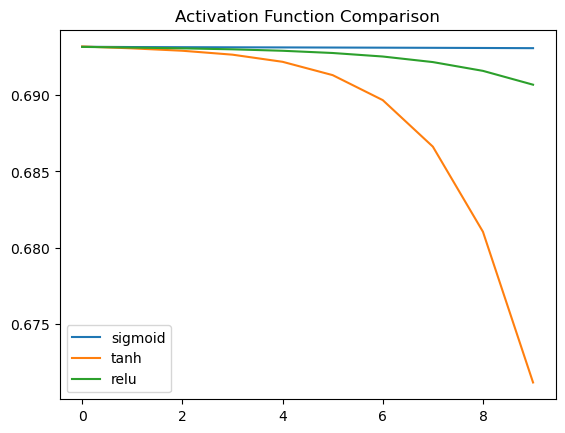

In [15]:
# ----------------------------
# Activatio Function Comparision
# ----------------------------

activations = ["sigmoid", "tanh", "relu"]

for act in activations:
    print("\nTraining with:", act)
    params, losses = train(X_train, Y_train, [2, 10, 1],
                           activation=act, lr=0.01, epochs=1000)

    plt.plot(losses, label=act)

plt.legend()
plt.title("Activation Function Comparison")
plt.show()

In [16]:
# ----------------------------
# Regularization Experiment
# ----------------------------

print("Without Regularization")
train(X_train, Y_train, [2,10,1], activation="relu")

print("With L2")
train(X_train, Y_train, [2,10,1], activation="relu",
      lambda_reg=0.1, reg_type="L2")

print("With L1")
train(X_train, Y_train, [2,10,1], activation="relu",
      lambda_reg=0.1, reg_type="L1")

Without Regularization
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6931
Epoch 200, Loss: 0.6931
Epoch 300, Loss: 0.6930
Epoch 400, Loss: 0.6929
Epoch 500, Loss: 0.6928
Epoch 600, Loss: 0.6925
Epoch 700, Loss: 0.6922
Epoch 800, Loss: 0.6916
Epoch 900, Loss: 0.6907
With L2
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6931
Epoch 200, Loss: 0.6931
Epoch 300, Loss: 0.6930
Epoch 400, Loss: 0.6929
Epoch 500, Loss: 0.6928
Epoch 600, Loss: 0.6925
Epoch 700, Loss: 0.6922
Epoch 800, Loss: 0.6916
Epoch 900, Loss: 0.6907
With L1
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6931
Epoch 200, Loss: 0.6931
Epoch 300, Loss: 0.6930
Epoch 400, Loss: 0.6930
Epoch 500, Loss: 0.6928
Epoch 600, Loss: 0.6926
Epoch 700, Loss: 0.6923
Epoch 800, Loss: 0.6918
Epoch 900, Loss: 0.6911


({'W1': array([[ 0.07335183, -0.04204508],
         [-0.00957849,  0.03106984],
         [-0.00101417, -0.00112871],
         [-0.00793908,  0.0288829 ],
         [-0.01576805,  0.02944414],
         [-0.00323247, -0.00348049],
         [-0.0029387 , -0.01490425],
         [-0.01712938, -0.00349247],
         [-0.0182823 ,  0.02647772],
         [-0.01012426, -0.01173601]]),
  'b1': array([[ 4.76820179e-02],
         [ 1.41711365e-02],
         [-4.29138809e-05],
         [ 1.18408244e-02],
         [ 2.28169730e-02],
         [-8.38373487e-05],
         [-6.13859013e-03],
         [ 1.28288866e-03],
         [ 2.39254310e-02],
         [ 4.51177495e-04]]),
  'W2': array([[ 9.80659278e-02, -3.19159143e-02, -6.35845876e-07,
          -3.08014293e-02, -4.02987998e-02, -2.07268795e-06,
          -7.33868149e-03, -6.30704220e-03, -3.93395410e-02,
          -3.88892075e-03]]),
  'b2': array([[-0.00154288]])},
 [np.float64(0.6931916228778137),
  np.float64(0.6931472744430118),
  np.float64(0

In [17]:
# ----------------------------
# Hyperparameter Tuning
# ----------------------------

learning_rates = [0.001, 0.01, 0.1]

for lr in learning_rates:
    print(f"\nLearning Rate: {lr}")
    train(X_train, Y_train, [2,10,1], lr=lr, epochs=500)


Learning Rate: 0.001
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6932
Epoch 200, Loss: 0.6932
Epoch 300, Loss: 0.6932
Epoch 400, Loss: 0.6931

Learning Rate: 0.01
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6931
Epoch 200, Loss: 0.6931
Epoch 300, Loss: 0.6930
Epoch 400, Loss: 0.6929

Learning Rate: 0.1
Epoch 0, Loss: 0.6932
Epoch 100, Loss: 0.6894
Epoch 200, Loss: 0.5292
Epoch 300, Loss: 0.3334
Epoch 400, Loss: 0.3049
